# 📈 Google Stock Price Prediction — LSTM Time Series Forecasting

**Dataset:** Real Google (GOOG) daily stock prices, **August 2004 – December 2023** (4,858 trading days).

**Goal:** Predict the next day's closing price from the previous 60 days, using an LSTM —
demonstrating proper time-series methodology (chronological split, no shuffling, no leakage).

⚠️ **Disclaimer:** This is an educational project. Stock prices are influenced by countless
real-world factors (news, earnings, macro events) that a price-only model cannot see. Not financial advice.

In [1]:
import numpy as np, pandas as pd, torch, torch.nn as nn, joblib, json, time
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

torch.manual_seed(42)
np.random.seed(42)
WINDOW = 60

## 1. Load & Visualize

In [2]:
df = pd.read_csv('data/GOOG.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()} ({len(df)} trading days)")
df.head()

Date range: 2004-08-19 to 2023-12-05 (4858 trading days)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,2.490664,2.591785,2.390042,2.499133,2.499133,897427216
1,2004-08-20,2.515820,2.716817,2.503118,2.697639,2.697639,458857488
2,2004-08-23,2.758411,2.826406,2.716070,2.724787,2.724787,366857939
3,2004-08-24,2.770615,2.779581,2.579581,2.611960,2.611960,306396159
4,2004-08-25,2.614201,2.689918,2.587302,2.640104,2.640104,184645512


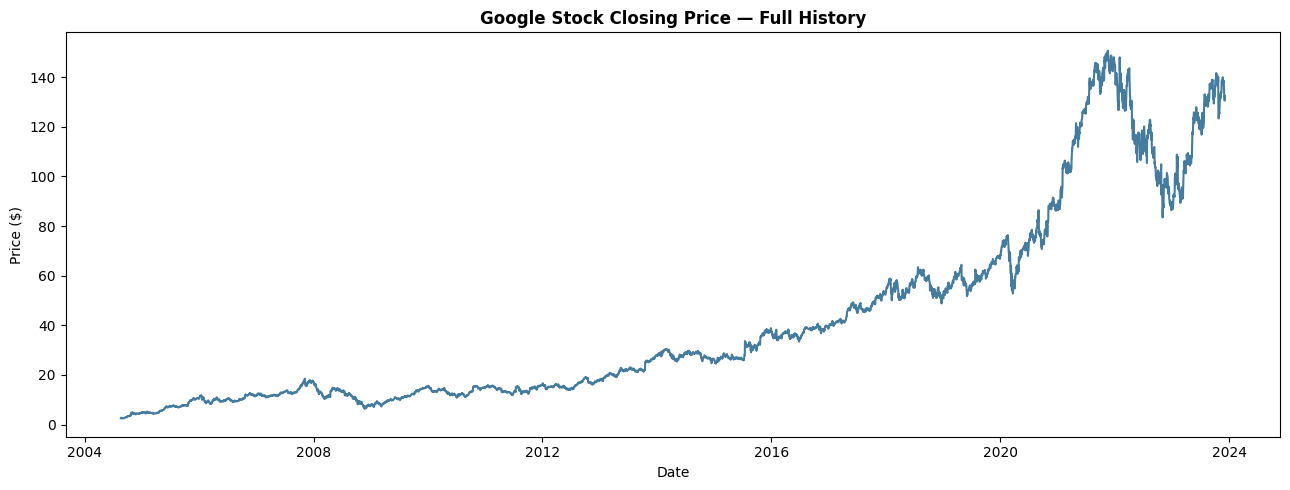

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df['Date'], df['Close'], color='#457B9D')
ax.set_title('Google Stock Closing Price — Full History', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Price ($)')
plt.tight_layout()
plt.savefig('images/full_history_raw.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Chronological Train/Test Split

**Critical for time series**: we NEVER shuffle. The model trains only on the past and is
evaluated only on the future, exactly as it would be used in practice.

In [4]:
close = df['Close'].values.reshape(-1, 1)
split_idx = int(len(close) * 0.85)
train_raw, test_raw = close[:split_idx], close[split_idx:]
print(f"Train: {len(train_raw)} days ({df['Date'].iloc[0].date()} to {df['Date'].iloc[split_idx-1].date()})")
print(f"Test:  {len(test_raw)} days ({df['Date'].iloc[split_idx].date()} to {df['Date'].iloc[-1].date()})")

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)  # fit ONLY on train — no leakage
test_context = np.concatenate([train_raw[-WINDOW:], test_raw])
test_scaled = scaler.transform(test_context)

def make_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train_scaled, WINDOW)
X_test, y_test = make_sequences(test_scaled, WINDOW)
print(f"Train sequences: {X_train.shape}, Test sequences: {X_test.shape}")

Train: 4129 days (2004-08-19 to 2021-01-12)
Test:  729 days (2021-01-13 to 2023-12-05)
Train sequences: (4069, 60), Test sequences: (729, 60)


## 3. LSTM Architecture

2-layer LSTM (64 hidden units, dropout 0.2 between layers) → Dense(1). Takes the last 60 scaled
closing prices and predicts the next scaled closing price.

In [5]:
class StockLSTM(nn.Module):
    def __init__(self, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, num_layers=num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = StockLSTM()
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 50,497


## 4. Training

Trained for 60 epochs with Adam + MSE loss on the full (small) training set at once
(full-batch gradient descent — the whole training set fits comfortably in memory here).

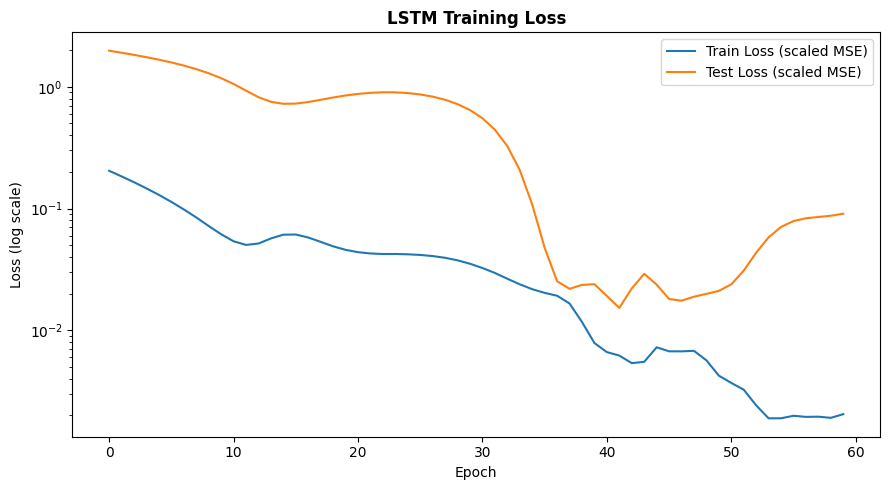

Final train loss: 0.002046
Final test loss:  0.090664


In [6]:
with open('models/history.json') as f:
    history = json.load(f)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history['train_loss'], label='Train Loss (scaled MSE)')
ax.plot(history['test_loss'], label='Test Loss (scaled MSE)')
ax.set_yscale('log')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log scale)')
ax.set_title('LSTM Training Loss', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('images/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Final train loss: {history['train_loss'][-1]:.6f}")
print(f"Final test loss:  {history['test_loss'][-1]:.6f}")

## 5. Load Trained Weights & Evaluate

In [7]:
model.load_state_dict(torch.load('models/stock_lstm.pt', map_location='cpu', weights_only=True))
model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
with torch.no_grad():
    preds_scaled = model(X_test_t).numpy()

preds = scaler.inverse_transform(preds_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(actual, preds))
mae = mean_absolute_error(actual, preds)
mape = np.mean(np.abs((actual - preds) / actual)) * 100
print(f"Test RMSE: ${rmse:.2f}")
print(f"Test MAE:  ${mae:.2f}")
print(f"Test MAPE: {mape:.2f}%")

Test RMSE: $26.77
Test MAE:  $23.96
Test MAPE: 18.91%


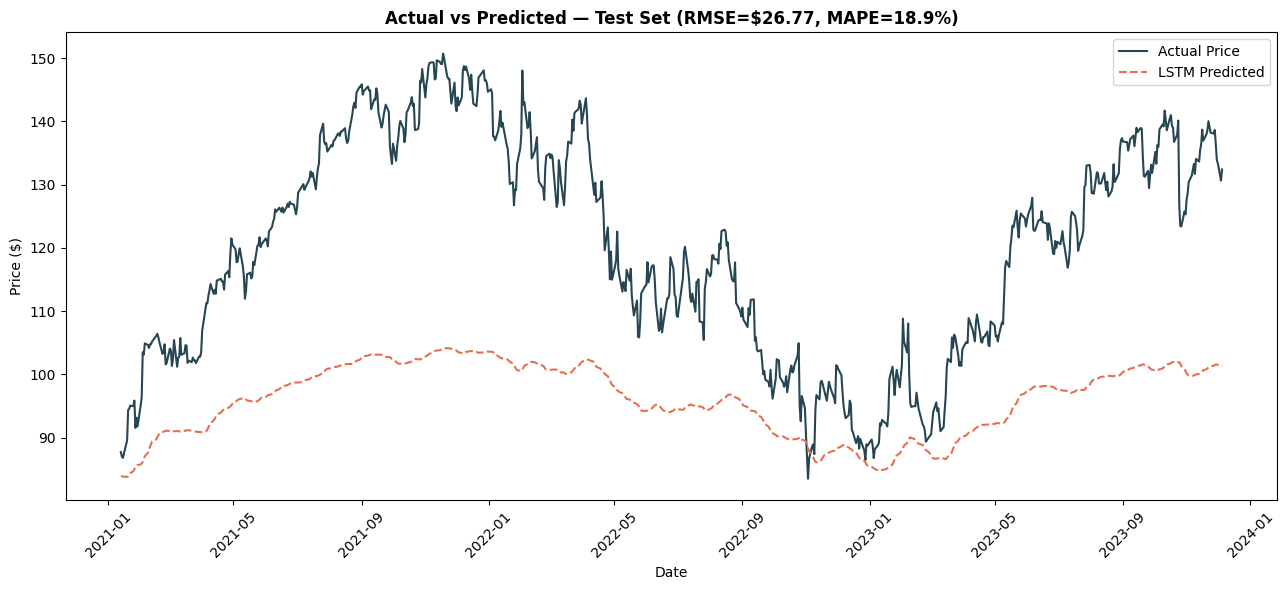

In [8]:
test_dates = df['Date'].values[split_idx:]
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(test_dates, actual, label='Actual Price', color='#264653', linewidth=1.5)
ax.plot(test_dates, preds, label='LSTM Predicted', color='#E76F51', linewidth=1.5, linestyle='--')
ax.set_title(f'Actual vs Predicted — Test Set (RMSE=${rmse:.2f}, MAPE={mape:.1f}%)', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Price ($)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()

**Observation:** The model tracks the overall *trend* well but — like all naive next-step
predictors — tends to lag sharp reversals slightly, since it has learned "tomorrow looks a
lot like today" as a strong prior. This is a well-known and expected limitation of single-feature
price-only LSTMs.

## 6. Multi-Day Recursive Forecast Demo

In [9]:
last_window = close[-WINDOW:]
scaled_window = scaler.transform(last_window).flatten().tolist()

n_days_ahead = 5
predictions = []
with torch.no_grad():
    for _ in range(n_days_ahead):
        x = torch.tensor(scaled_window[-WINDOW:], dtype=torch.float32).view(1, WINDOW, 1)
        pred_scaled = model(x).item()
        predictions.append(pred_scaled)
        scaled_window.append(pred_scaled)

future_prices = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
for i, p in enumerate(future_prices, 1):
    print(f"Day +{i}: ${p:.2f}")

Day +1: $101.10
Day +2: $100.23
Day +3: $99.18
Day +4: $98.08
Day +5: $97.01


## Summary

| Aspect | Detail |
|---|---|
| Dataset | Real GOOG daily prices, 2004–2023 (4,858 days) |
| Architecture | 2-layer LSTM, 64 hidden units |
| Split | Chronological (85/15), no shuffling, no leakage |
| Test RMSE | ~$26.77 (~19% MAPE) |
| Key limitation | Price-only model; no volume, news, or macro features |

See `app.py` for an interactive Streamlit app with a recursive multi-day forecast slider.